In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import os

# Настройки визуализации
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Пути к файлам (работаем из папки notebooks)
DATA_PATH = '../data/traffic.csv'
OUTPUT_PATH = '../data/traffic_clean.csv'

# 2. Загрузка данных
df = pd.read_csv(DATA_PATH)
print(f"Исходный размер датасета: {df.shape}")
df.head()

Исходный размер датасета: (48120, 4)


,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [29]:
# 3. Базовый анализ структуры данных
print("--- Информация о типах данных ---")
df.info()

print("\n--- Проверка на пропущенные значения ---")
print(df.isnull().sum())

print("\n--- Проверка на полные дубликаты строк ---")
print(f"Дубликатов: {df.duplicated().sum()}")

print("\n--- Распределение данных по перекресткам ---")
print(df.groupby('Junction').size())

--- Информация о типах данных ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB

--- Проверка на пропущенные значения ---
DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64

--- Проверка на полные дубликаты строк ---
Дубликатов: 0

--- Распределение данных по перекресткам ---
Junction
1    14592
2    14592
3    14592
4     4344
dtype: int64


In [30]:
# 4. Преобразование типов и валидация временной сетки
df['DateTime'] = pd.to_datetime(df['DateTime'])
df.set_index('DateTime', inplace=True)
df.drop('ID', axis=1, inplace=True, errors='ignore')

# Отфильтруем полные ряды (Junction 1, 2, 3)
df_clean = df[df['Junction'].isin([1, 2, 3])].copy()

# Проверим, нет ли скрытых пропусков во временной сетке для каждого перекрестка
for j in df_clean['Junction'].unique():
    sub = df_clean[df_clean['Junction'] == j]
    full_range = pd.date_range(start=sub.index.min(), end=sub.index.max(), freq='h')
    missing = len(full_range) - len(sub)
    print(f"Перекресток {j}: Период с {sub.index.min()} по {sub.index.max()}. Скрытых пропусков часов: {missing}")

Перекресток 1: Период с 2015-11-01 00:00:00 по 2017-06-30 23:00:00. Скрытых пропусков часов: 0
Перекресток 2: Период с 2015-11-01 00:00:00 по 2017-06-30 23:00:00. Скрытых пропусков часов: 0
Перекресток 3: Период с 2015-11-01 00:00:00 по 2017-06-30 23:00:00. Скрытых пропусков часов: 0


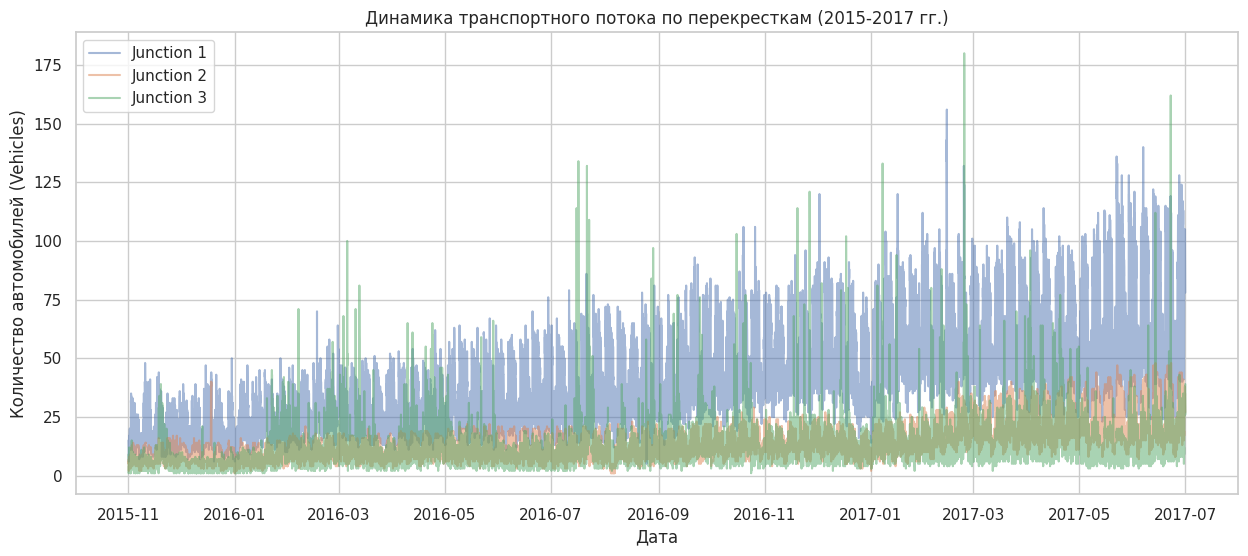

In [31]:
# 5. Визуальный анализ временных рядов
plt.figure(figsize=(15, 6))
for j in df_clean['Junction'].unique():
    subset = df_clean[df_clean['Junction'] == j]
    plt.plot(subset.index, subset['Vehicles'], label=f'Junction {j}', alpha=0.5)

plt.title('Динамика транспортного потока по перекресткам (2015-2017 гг.)')
plt.xlabel('Дата')
plt.ylabel('Количество автомобилей (Vehicles)')
plt.legend()
plt.show()

In [32]:
# 6. Анализ стационарности (Тест Дики-Фуллера)
print("--- Результаты теста ADF ---")
for j in df_clean['Junction'].unique():
    series = df_clean[df_clean['Junction'] == j]['Vehicles']
    result = adfuller(series.dropna())
    print(f"Junction {j}: ADF Statistic = {result[0]:.4f}, p-value = {result[1]:.4e}")
    if result[1] <= 0.05:
        print(f" -> Ряд СТАЦИОНАРЕН (p <= 0.05)")
    else:
        print(f" -> Ряд НЕСТАЦИОНАРЕН (требуется взятие разностей)")

--- Результаты теста ADF ---
Junction 1: ADF Statistic = -7.1481, p-value = 3.1938e-10
 -> Ряд СТАЦИОНАРЕН (p <= 0.05)
Junction 2: ADF Statistic = -8.0411, p-value = 1.8464e-12
 -> Ряд СТАЦИОНАРЕН (p <= 0.05)
Junction 3: ADF Statistic = -8.2366, p-value = 5.8673e-13
 -> Ряд СТАЦИОНАРЕН (p <= 0.05)


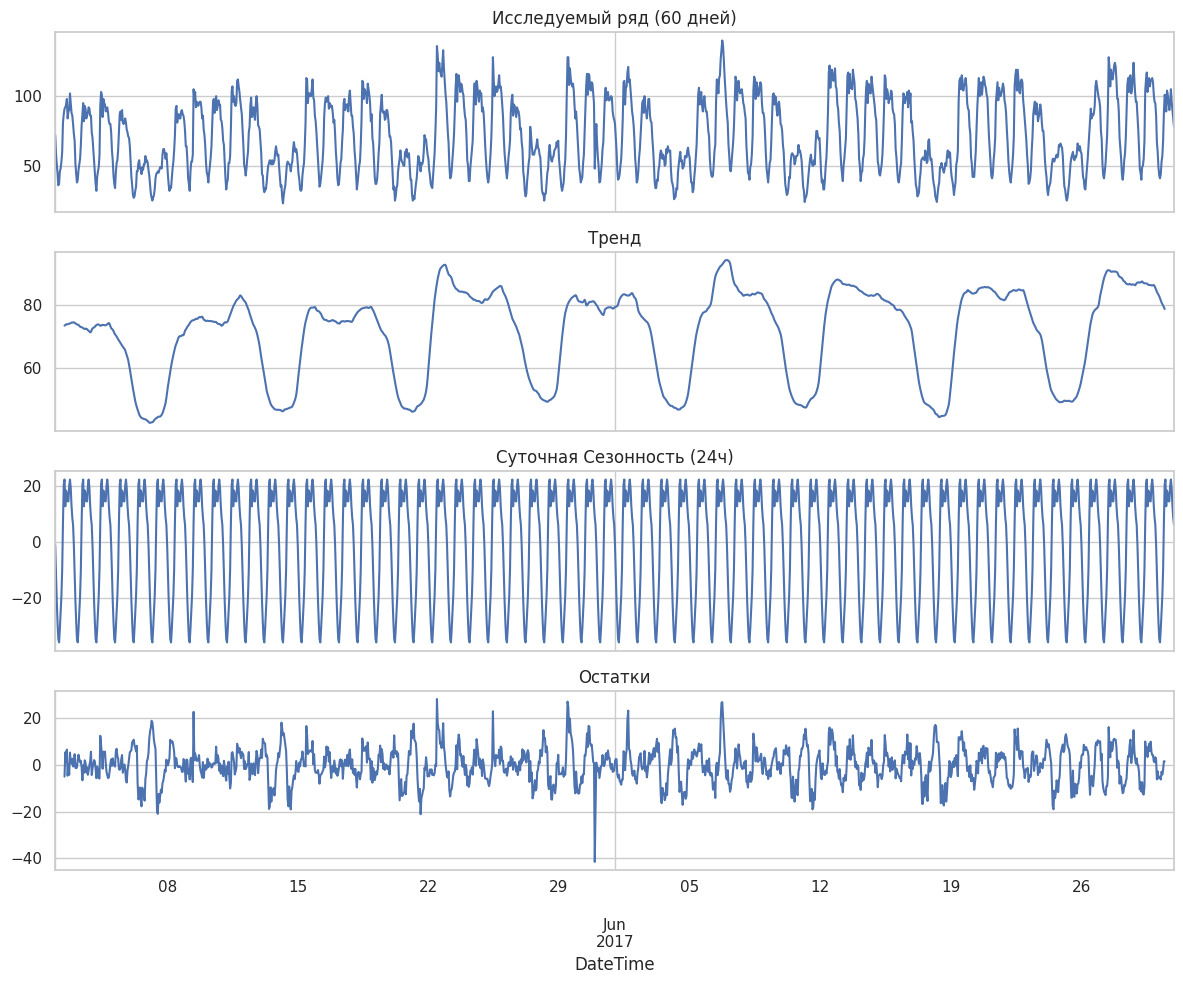

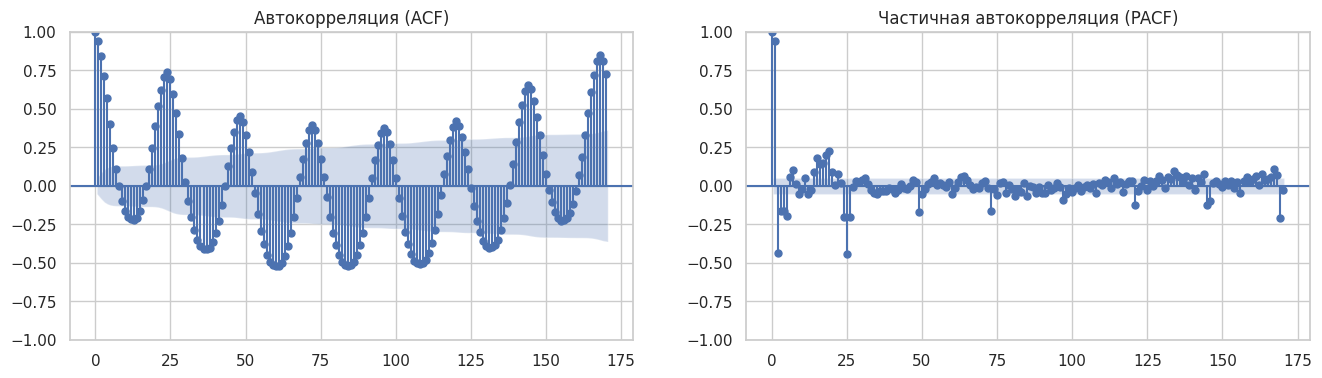

In [33]:
# 7. Анализ сезонности (Возьмем срез за 2 месяца для Junction 1, чтобы не перегружать вычисления)
sample_series = df_clean[df_clean['Junction'] == 1]['Vehicles'].last('60D')

# Декомпозиция (Суточная сезонность: период = 24 часа)
decomp = seasonal_decompose(sample_series, model='additive', period=24)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
decomp.observed.plot(ax=axes[0], title='Исследуемый ряд (60 дней)')
decomp.trend.plot(ax=axes[1], title='Тренд')
decomp.seasonal.plot(ax=axes[2], title='Суточная Сезонность (24ч)')
decomp.resid.plot(ax=axes[3], title='Остатки')
plt.tight_layout()
plt.show()

# Коррелограммы (ACF / PACF) для выявления недельной (168ч) зависимости
fig, ax = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(sample_series, lags=170, ax=ax[0], title='Автокорреляция (ACF)')
plot_pacf(sample_series, lags=170, ax=ax[1], title='Частичная автокорреляция (PACF)')
plt.show()

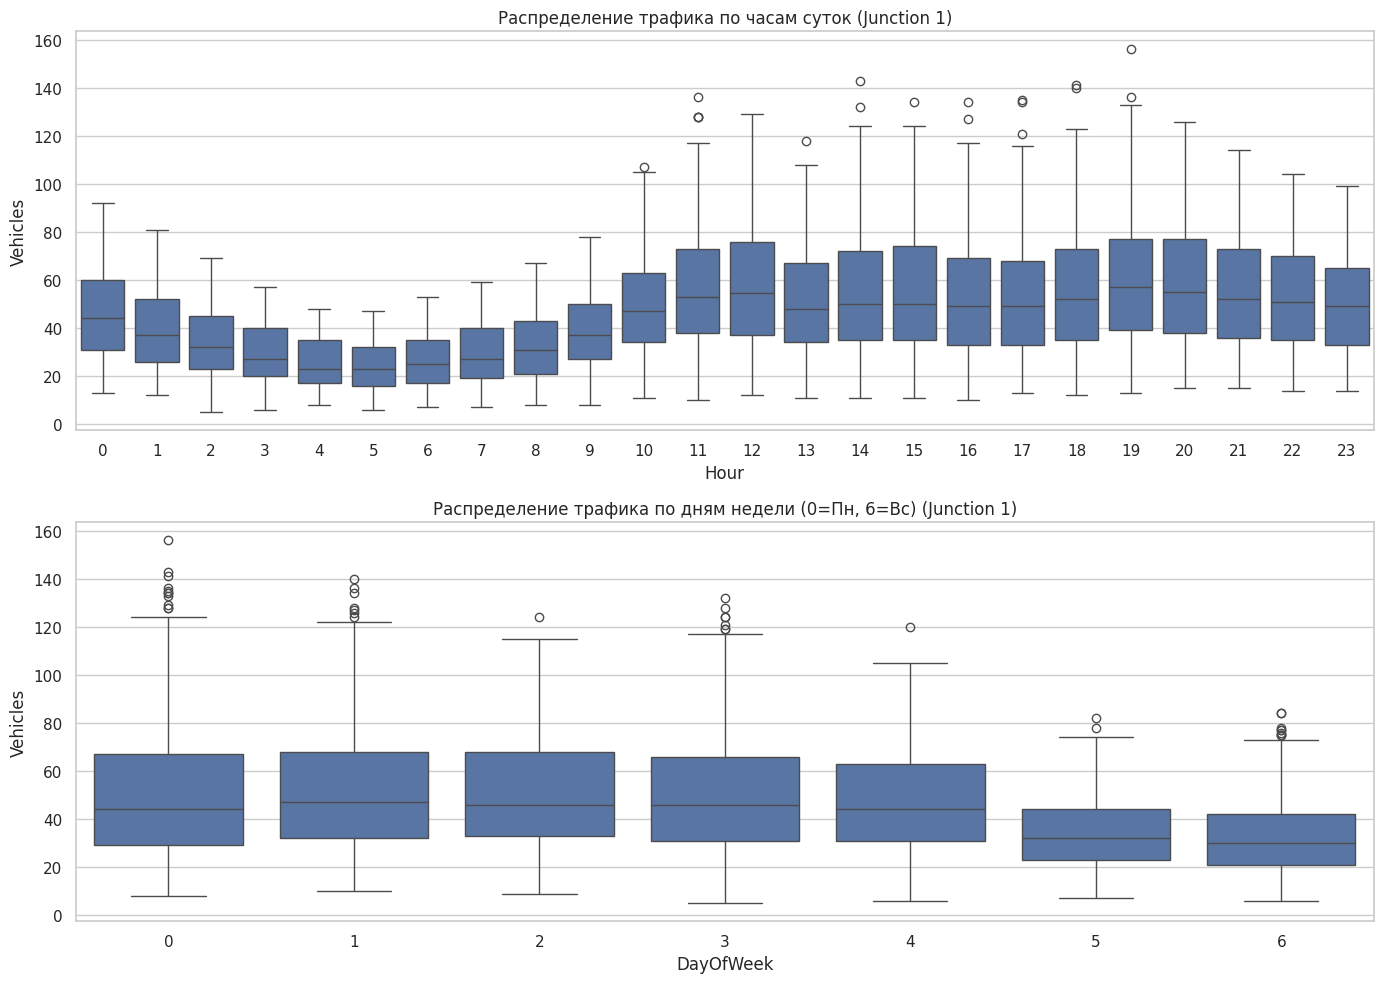

In [34]:
# 8. Фиче-инжиниринг в рамках EDA (Анализ внутрисуточных и внутринедельных паттернов)
df_clean['Hour'] = df_clean.index.hour
df_clean['DayOfWeek'] = df_clean.index.dayofweek

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
sns.boxplot(data=df_clean[df_clean['Junction']==1], x='Hour', y='Vehicles', ax=axes[0])
axes[0].set_title('Распределение трафика по часам суток (Junction 1)')

sns.boxplot(data=df_clean[df_clean['Junction']==1], x='DayOfWeek', y='Vehicles', ax=axes[1])
axes[1].set_title('Распределение трафика по дням недели (0=Пн, 6=Вс) (Junction 1)')
plt.tight_layout()
plt.show()

In [35]:
# 9. Корректный поиск аномалий (Изолированно внутри каждого перекрестка по IQR)
def remove_outliers_iqr(group):
    Q1 = group['Vehicles'].quantile(0.25)
    Q3 = group['Vehicles'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Вместо удаления строк (чтобы не рвать временную сетку для моделей АВР), 
    # мы клиппируем (винсоризируем) экстремальные выбросы до границ IQR.
    group['Vehicles'] = np.clip(group['Vehicles'], lower_bound, upper_bound)
    return group

df_prepared = df_clean.groupby('Junction', group_keys=False).apply(remove_outliers_iqr)
print("Аномалии обработаны (значения ограничены по границам IQR локально для каждого ряда).")

Аномалии обработаны (значения ограничены по границам IQR локально для каждого ряда).


In [36]:
# 10. Сохранение подготовленных данных
# Сбрасываем индекс, чтобы вернуть DateTime в колонку (требование для statsforecast/mlforecast)
df_final = df_prepared.reset_index()

# Переименовываем под стандарт фреймворков Nixtla (unique_id, ds, y)
df_final = df_final.rename(columns={
    'Junction': 'unique_id',
    'DateTime': 'ds',
    'Vehicles': 'y'
})

# Оставляем только нужные для пайплайна колонки
df_final = df_final[['unique_id', 'ds', 'y']]

os.makedirs('../data', exist_ok=True)
df_final.to_csv(OUTPUT_PATH, index=False)
print(f"Данные успешно подготовлены и сохранены в {OUTPUT_PATH}. Количество строк: {len(df_final)}")
df_final.head()

Данные успешно подготовлены и сохранены в ../data/traffic_clean.csv. Количество строк: 43776


,unique_id,ds,y
0,1,2015-11-01 00:00:00,15.0
1,1,2015-11-01 01:00:00,13.0
2,1,2015-11-01 02:00:00,10.0
3,1,2015-11-01 03:00:00,7.0
4,1,2015-11-01 04:00:00,9.0
